In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import Tensor
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.ctmc import CTMCDataset
from peint.models.modules.ctmc_module import CTMCModule
from peint.models.nets.ctmc import NeuralCTMC

from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab

from tqdm import tqdm
tqdm.pandas()

In [8]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-10-20_20-11-13/checkpoints")
ckpt_path = ckpt_dir / "epoch_004.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = CTMCModule.load_from_checkpoint(ckpt_path, map_location=device, strict=False)
module = module.eval()

net: NeuralCTMC = module.net
vocab: Vocab = net.vocab

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [9]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name
    dataset = CTMCDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        sep_token=".",
        vocab=vocab,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []

    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        
        x, y, t, x_sizes = batch

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            Q: Tensor = net(x, x_sizes=x_sizes)  # (B, L, V, V)
            log_probs: Tensor = module.forward(x, t, x_sizes=x_sizes, Q=Q)  # (B, L, V)

        # Keep unreduced to get per-site time likelihood (B, L)
        nll = F.cross_entropy(
            log_probs.transpose(-1, -2),
            y,
            ignore_index=vocab.pad_idx,
            reduction="none",
        ).detach()

        # compute perplexity
        padding_mask = y != vocab.pad_idx
        ll = -nll * padding_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())
        bls.append(t.detach().cpu().numpy())
        nll_mean = (nll * padding_mask.float()).sum(dim=-1) / padding_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [14]:
# load the test dataset and infer log likelihoods with the CTMC model
# datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/extra/edges_joint/aa/dx.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

Inference:   0%|                                                                                                                                                                                               | 0/1180 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 30.00 MiB. GPU 0 has a total capacity of 79.25 GiB of which 22.12 MiB is free. Process 3164410 has 35.54 GiB memory in use. Including non-PyTorch memory, this process has 34.79 GiB memory in use. Process 3190961 has 8.86 GiB memory in use. Of the allocated memory 33.19 GiB is allocated by PyTorch, and 1.10 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
print('test perplexity: ', np.mean(ppl))
print(lls)

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch": bls[:,0],
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("ctmc_model_d4.csv", index=False)

In [ ]:
# plot the binned likelihoods according to the branch length
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(.15).astype(float)
binned_df = df.groupby("bl_bin").mean()

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(binned_df.branch_length, binned_df.ll, label="Binned log-likelihood", s=10)
ax.scatter(df.branch_length, df.ll, alpha=0.1, label="Log-likelihood per sample", s=5)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Log-Likelihood vs Branch Length (test set donor 4)")
ax.legend()
plt.show()

## Now let's try sampling some proteins from the ctmc model

In [ ]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

In [15]:
# first we try generating child sequences using the one-shot independent site method
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
ind_sim_child_hv_seqs, ind_sim_child_lt_seqs = [], []
dep_sim_child_hv_seqs, dep_sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 50

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes = batch

    # get heavy chain lengths
    hc_lens = x_sizes[:,0]
    hc_lens -= 2

    # decode the true parent and child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x[i].cpu().numpy()) for i in range(x.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))]
    true_pr_hv_seqs, true_pr_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_parent_seqs, hc_lens)])
    true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, hc_lens)])

    # sample a child sequence using the model
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        y_ind_decoded = net.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)
        y_dep_decoded = net.generate_with_fake_gillespie(t=t, x=x, x_sizes=x_sizes)

    sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
    sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_ind_child_seqs, hc_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_ind_child_seqs)])
    
    sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]
    sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_dep_child_seqs, hc_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_dep_child_seqs)])

    real_parent_hv_seqs.extend(true_pr_hv_seqs)
    real_parent_lt_seqs.extend(true_pr_lt_seqs)
    real_child_hv_seqs.extend(true_ch_hv_seqs)
    real_child_lt_seqs.extend(true_ch_lt_seqs)
    ind_sim_child_hv_seqs.extend(sim_ind_hv_seqs)
    ind_sim_child_lt_seqs.extend(sim_ind_lt_seqs)
    dep_sim_child_hv_seqs.extend(sim_dep_hv_seqs)
    dep_sim_child_lt_seqs.extend(sim_dep_lt_seqs)
    branch_lengths.extend(t.squeeze().detach().cpu().numpy().tolist())

    n_batches -= 1
    if n_batches == 0:
        break

Inference:   3%|█▉                                                                          | 49/1888 [04:00<2:30:14,  4.90s/it]


In [16]:
print(true_parent_seqs[0])
print(true_pr_hv_seqs[0])
print(true_pr_lt_seqs[0])
print()
print(true_child_seqs[0])
print(true_ch_hv_seqs[0])
print(true_ch_lt_seqs[0])
print()
print(sim_dep_child_seqs[0])
print(sim_dep_hv_seqs[0])
print(sim_dep_lt_seqs[0])

EVHLVESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSS.DIVLTQSPLSLPVTPGEPASISCRSTQSLLHTNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK
EVHLVESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSS
DIVLTQSPLSLPVTPGEPASISCRSTQSLLHTNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK

EVNLVESGGGLVQRGGSLRLSCAASGFTFGNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSS.DIVLTQSPLSLPVTPGEPASISCRSTQSLLHPNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK
EVNLVESGGGLVQRGGSLRLSCAASGFTFGNYAMSWVRQAPGKGLEWVLSISGSGNTTHYAESVKGRFTVSRDNSKNTLYVQMNSLRAGDTAIYYCAKSGKTVWSLDYWGQGTLVTVSS
DIVLTQSPLSLPVTPGEPASISCRSTQSLLHPNGYNYLDWYLQKPGQSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRMEAEDVGVYYCMQTLQNPPLTFGQGTRLEIK

EVHLVESGGGLVRPGGSLRLSCAASGFTFNKYAMNWVRQAPGKGLEWVLSISGSGNTTHYAE

In [ ]:
# calculate hamming distances between corresponding real and simulated sequences
hv_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, dep_sim_child_hv_seqs)]
lt_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, dep_sim_child_lt_seqs)]
_len = len(hv_ind_aa_hamming_dists)

data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_ind_aa_hamming_dists + hv_dep_aa_hamming_dists + lt_ind_aa_hamming_dists + lt_dep_aa_hamming_dists,
    "chain": ["heavy"] * 2 * _len + ["light"] * 2 * _len,
    "method": ["matrix exponential"] * _len + ["gillespie"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

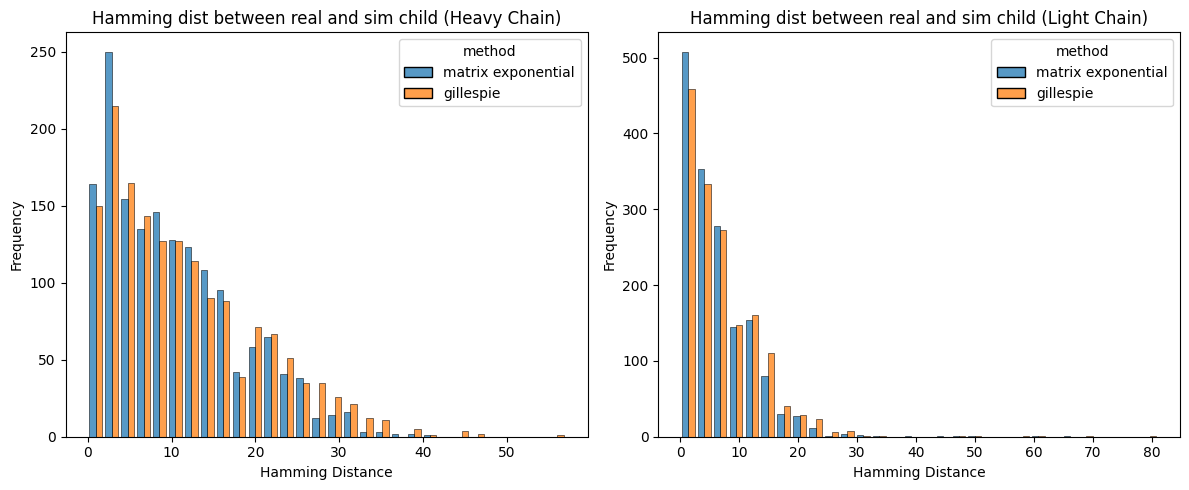

In [18]:
# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side) colored by method
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data_df[data_df["chain"] == "heavy"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[0], legend=True)
sns.histplot(data=data_df[data_df["chain"] == "light"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[1], legend=True)

# add labels and legend please
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency')
ax[1].set_title('Hamming dist between real and sim child (Light Chain)')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')
# ax[0].legend(title='Method')
# ax[1].legend(title='Method')

plt.tight_layout()
plt.show()

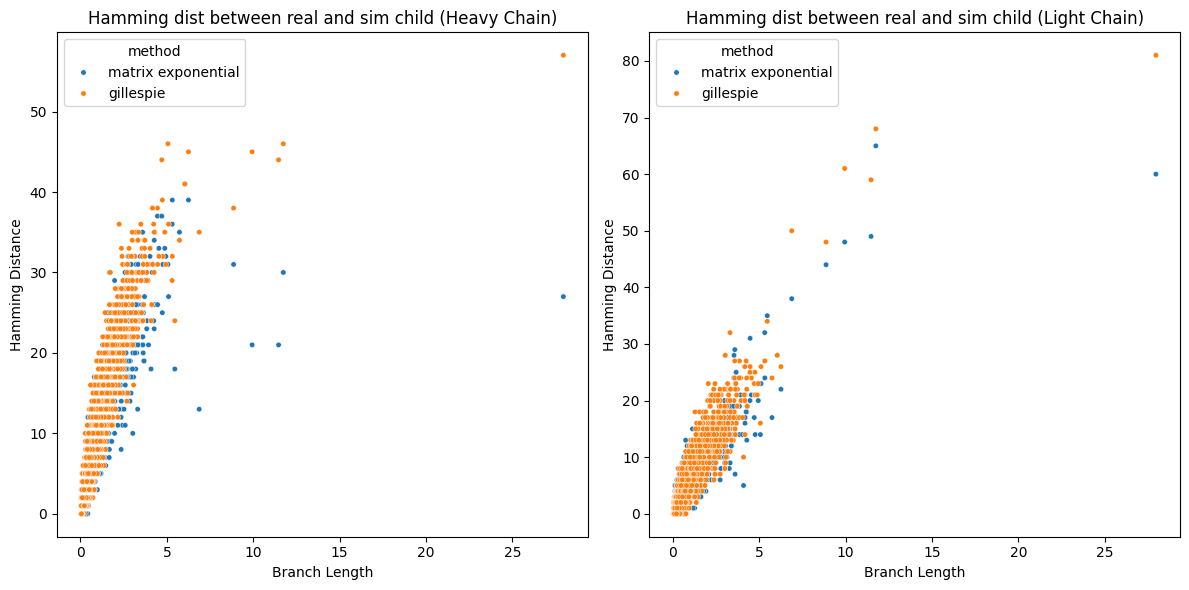

In [19]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=data_df[data_df["chain"] == "heavy"], x="bl", y="dist", hue="method", ax=ax[0], legend=True, s=15)
sns.scatterplot(data=data_df[data_df["chain"] == "light"], x="bl", y="dist", hue="method", ax=ax[1], legend=True, s=15)

# add titles and labels
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_title("Hamming dist between real and sim child (Light Chain)")
ax[1].set_xlabel("Branch Length")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [20]:
# calculate hamming distance between real parent and all child sequences, real and fake

hv_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, real_child_hv_seqs)]
hv_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, dep_sim_child_hv_seqs)]

lt_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, real_child_lt_seqs)]
lt_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, dep_sim_child_lt_seqs)]

_len = len(hv_real_hd)

hv_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_real_hd + hv_ind_hd + hv_dep_hd, 
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})
lt_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": lt_real_hd + lt_ind_hd + lt_dep_hd,
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

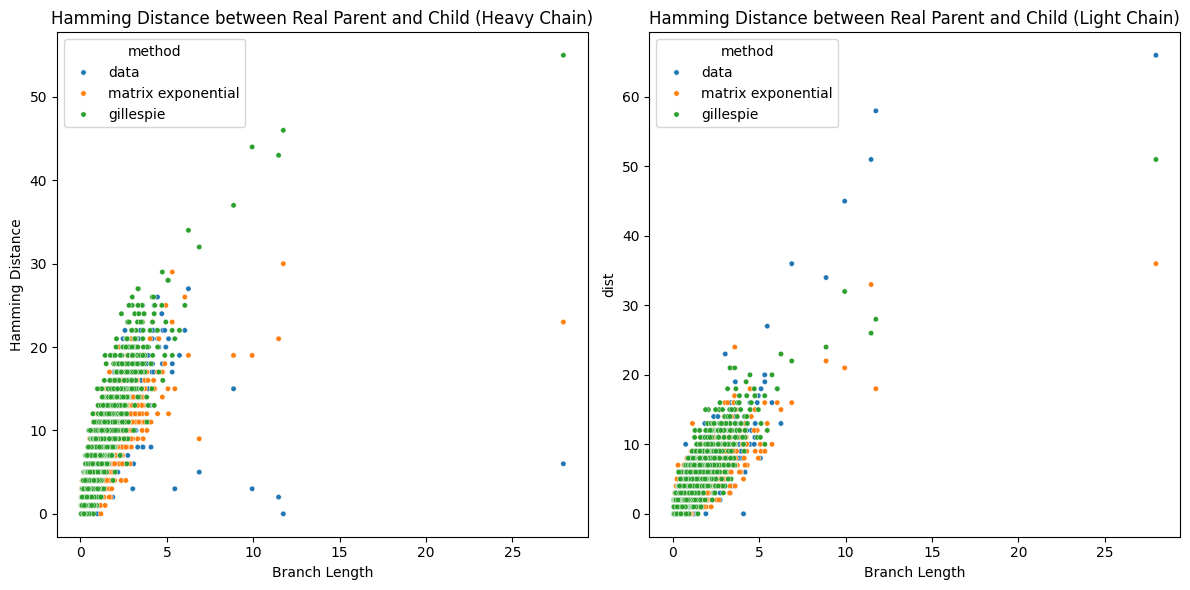

In [21]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=hv_data_df, x="bl", y="dist", hue="method", ax=ax[0], legend="full", s=15)
sns.scatterplot(data=lt_data_df, x="bl", y="dist", hue="method", ax=ax[1], legend="full", s=15)

ax[0].set_title("Hamming Distance between Real Parent and Child (Heavy Chain)")
ax[1].set_title("Hamming Distance between Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

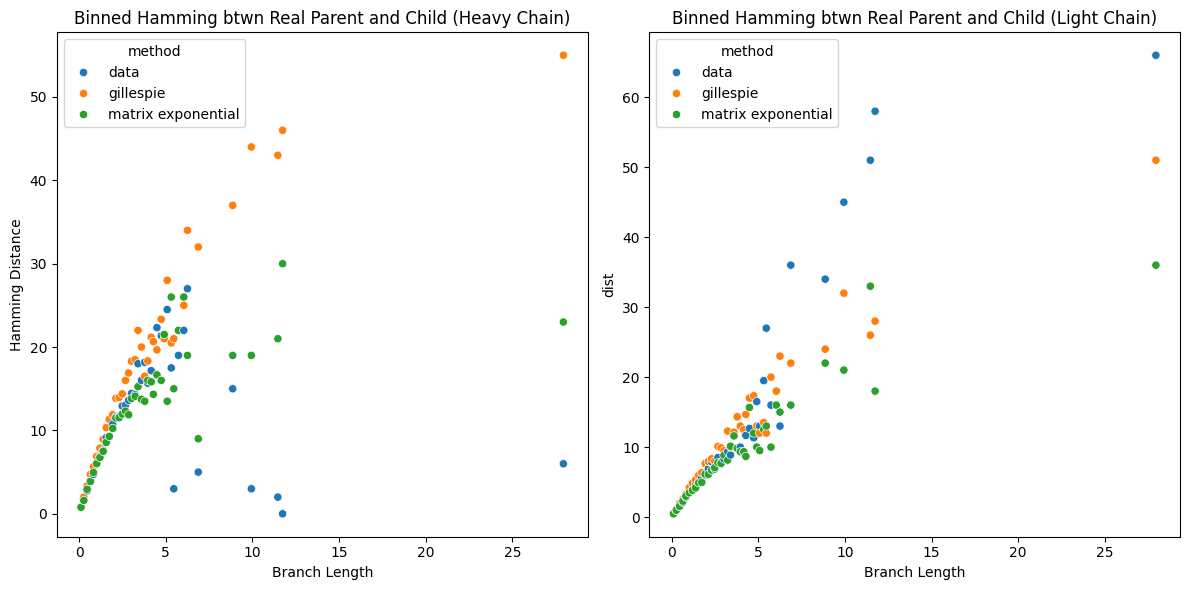

In [22]:
# do this plot again, but now bin by branch length
hv_quantile, lt_quantile = hv_data_df.bl.quantile(0.15), lt_data_df.bl.quantile(0.15)
hv_data_df["bl_bin"] = hv_data_df.bl // hv_quantile.astype(float)
lt_data_df["bl_bin"] = lt_data_df.bl // lt_quantile.astype(float)

binned_hv_u = hv_data_df.groupby(by=["bl_bin", "method"]).mean()
binned_lt_u = lt_data_df.groupby(by=["bl_bin", "method"]).mean()
binned_hv_s = hv_data_df.groupby(by=["bl_bin", "method"]).std()
binned_lt_s = lt_data_df.groupby(by=["bl_bin", "method"]).std()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=binned_hv_u, x="bl", y="dist", hue="method", ax=ax[0], legend="full")
sns.scatterplot(data=binned_lt_u, x="bl", y="dist", hue="method", ax=ax[1], legend="full")

# Add confidence intervals
# ax[0].fill_between(
#     binned_hv_u.bl,
#     binned_hv_u.dist - binned_hv_s.dist,
#     binned_hv_u.dist + binned_hv_s.dist,
#     alpha=0.2,
# )
# ax[1].fill_between(
#     binned_lt_u.bl,
#     binned_lt_u.dist - binned_lt_s.dist,
#     binned_lt_u.dist + binned_lt_s.dist,
#     alpha=0.2,
# )

ax[0].set_title("Binned Hamming btwn Real Parent and Child (Heavy Chain)")
ax[1].set_title("Binned Hamming btwn Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [24]:
# save sampled sequences to disk, use different file for dep and ind methods
# format should be csv with real parent, real child, simulated child, and branch length

# Create DataFrames for independent and dependent methods
ind_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": ind_sim_child_hv_seqs,
    "sim_child_lt": ind_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

dep_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": dep_sim_child_hv_seqs,
    "sim_child_lt": dep_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

# Save to CSV files
ind_df.to_csv("results/gen_eval/ctmc_mat_exp.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie.csv", index=False)

## Sampling from same parent with different branch lengths


In [18]:
# first we try generating child sequences using the one-shot independent site method
batch = next(iter(dataloader))
batch = [b.to(device) for b in batch]
x, y, t, x_sizes = batch

hv_sz = x_sizes[0, 0] - 2

real_parent_seq = decode_sequence_from_toks(x[0].cpu().numpy())
real_child_seq = decode_sequence_from_toks(y[0].cpu().numpy())
real_pr_hv_seq = real_parent_seq[:hv_sz]
real_pr_lt_seq = real_parent_seq[hv_sz+1:]
real_ch_hv_seq = real_child_seq[:hv_sz]
real_ch_lt_seq = real_child_seq[hv_sz+1:]

branch_lengths = torch.from_numpy(np.linspace(0, 50, 100))
x = x[0].repeat(len(branch_lengths), 1).cuda()
x_sizes = x_sizes[0].repeat(len(branch_lengths), 1).cuda()
ts = branch_lengths.reshape(-1, 1).cuda()

with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    y_ind_decoded = net.generate_with_independent_sites(t=ts, x=x, x_sizes=x_sizes)
    y_dep_decoded = net.generate_with_fake_gillespie(t=ts, x=x, x_sizes=x_sizes, max_decode_steps=2048)

sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hv_sz], seq[hv_sz+1:]) for seq in sim_ind_child_seqs])

sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]
sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hv_sz], seq[hv_sz+1:]) for seq in sim_dep_child_seqs])

 86%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                          | 880/1024 [01:52<00:18,  7.84it/s]


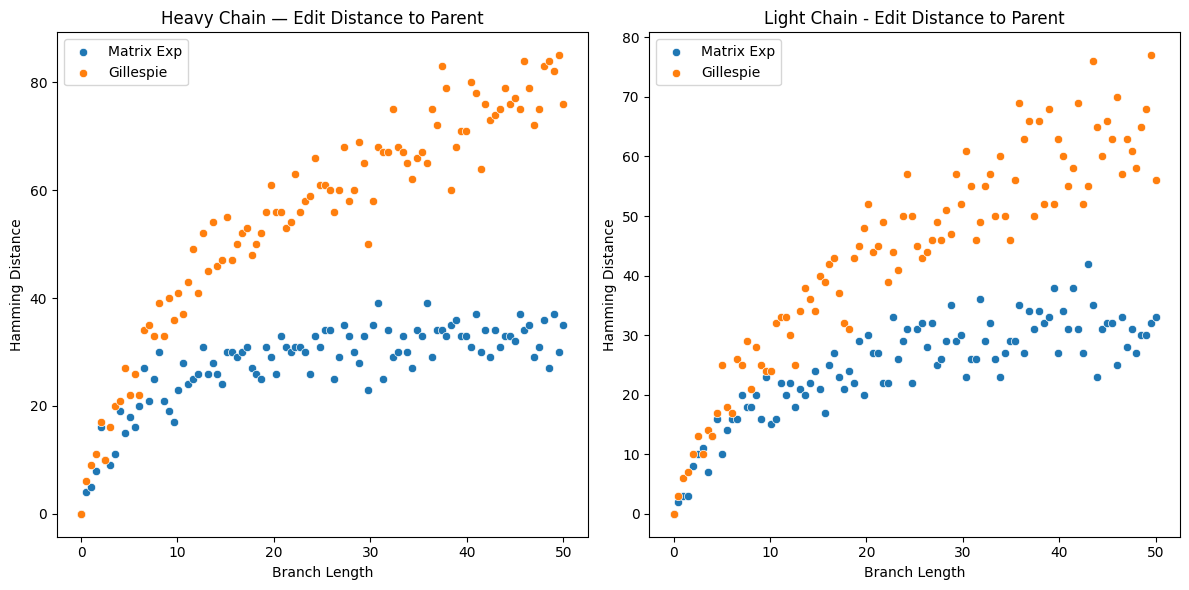

In [19]:
# calculate hamming distance between each of the simulated sequences and the real parent sequence
hv_hmd_ind = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_ind_hv_seqs]
hv_hmd_dep = [compute_hamming_distance(real_pr_hv_seq, seq) for seq in sim_dep_hv_seqs]
lt_hmd_ind = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_ind_lt_seqs]
lt_hmd_dep = [compute_hamming_distance(real_pr_lt_seq, seq) for seq in sim_dep_lt_seqs]

# plot hmd against branch lengths, color by method
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(x=branch_lengths, y=hv_hmd_ind, ax=ax[0], label="Matrix Exp")
sns.scatterplot(x=branch_lengths, y=hv_hmd_dep, ax=ax[0], label="Gillespie")
sns.scatterplot(x=branch_lengths, y=lt_hmd_ind, ax=ax[1], label="Matrix Exp")
sns.scatterplot(x=branch_lengths, y=lt_hmd_dep, ax=ax[1], label="Gillespie")

ax[0].set_title("Heavy Chain — Edit Distance to Parent")
ax[1].set_title("Light Chain - Edit Distance to Parent")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()


In [21]:
# save the sampled sequences to disk

ind_data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_ind_hv_seqs,
    "lt_seqs": sim_ind_lt_seqs,
    "hv_hmd": hv_hmd_ind,
    "lt_hmd": lt_hmd_ind,
}
dep_data = {
    "branch_lengths": branch_lengths.cpu().numpy(),
    "hv_par": [real_pr_hv_seq] * len(branch_lengths),
    "lt_par": [real_pr_lt_seq] * len(branch_lengths),
    "hv_seqs": sim_dep_hv_seqs,
    "lt_seqs": sim_dep_lt_seqs,
    "hv_hmd": hv_hmd_dep,
    "lt_hmd": lt_hmd_dep,
}

# save to csv files
ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

ind_df.to_csv("results/gen_eval/ctmc_mat_exp_vary_t.csv", index=False)
dep_df.to_csv("results/gen_eval/ctmc_gillespie_vary_t.csv", index=False)

## Generate multihop trajectories

In [85]:
import random
from Bio.Seq import Seq
from evo.phylogeny import df_to_ete3_tree
from peint.models.frameworks.peint import simulate_evolution_with_rejection_sampling

In [29]:
data_dir = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/raw")

heavy = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igh_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
kappa = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igk_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)
lambd = pd.read_csv(data_dir / 'wyatt-10x-1p5m_paired-igl_fs-all_pcp_2024-11-21.csv.gz', compression='gzip', index_col=0)

heavy['family'] = heavy['sample_id'] + '_' + heavy['family'].astype(str)
kappa['family'] = kappa['sample_id'] + '_' + kappa['family'].astype(str)
lambd['family'] = lambd['sample_id'] + '_' + lambd['family'].astype(str)

heavy['edge_id'] = heavy['family'] + ';' + heavy['parent_name'] + ';' + heavy['child_name']
kappa['edge_id'] = kappa['family'] + ';' + kappa['parent_name'] + ';' + kappa['child_name']
lambd['edge_id'] = lambd['family'] + ';' + lambd['parent_name'] + ';' + lambd['child_name']

In [30]:
keep_kappa = (kappa.edge_id.isin(heavy.edge_id)) & ~(kappa.edge_id.isin(lambd.edge_id))
keep_lambd = (lambd.edge_id.isin(heavy.edge_id)) & ~(lambd.edge_id.isin(kappa.edge_id))
kappa = kappa[keep_kappa]
lambd = lambd[keep_lambd]
keep_heavy = (heavy.edge_id.isin(kappa.edge_id)) | (heavy.edge_id.isin(lambd.edge_id))
heavy = heavy[keep_heavy]

In [31]:
merge_cols = ['sample_id', 'family', 'parent_name', 'child_name', 'edge_id']
keep_cols = ['parent', 'child', 'branch_length', 'depth', 'distance', 'v_gene', 'cdr1_codon_start', 
             'cdr1_codon_end', 'cdr2_codon_start', 'cdr2_codon_end', 'cdr3_codon_start', 'cdr3_codon_end',
             'parent_is_naive', 'child_is_leaf']
keep_cols = merge_cols + keep_cols

In [32]:
heavy_kappa = pd.merge(heavy[keep_cols], kappa[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
heavy_lambd = pd.merge(heavy[keep_cols], lambd[keep_cols], on=merge_cols, how='inner', suffixes=('_heavy', '_light'))
full_df = pd.concat([heavy_kappa, heavy_lambd], axis=0)

In [37]:
family = 'd4_203694-igk-203694'
edges = full_df[full_df.family == family]

edges = edges.rename(columns={'branch_length_heavy':'branch_length'})
edges['branch_length'] /= edges['branch_length'].mean()

tree = df_to_ete3_tree(edges[['parent_name', 'child_name', 'branch_length']])
print(tree.get_ascii())


                                                                                            /-AAACGGGTCATTCACT-1-1279069_contig_h
                                                                                      /Node16
                                                                                /Node15     \-CAGATCAAGGACACCA-1-1287171_contig_h
                                                                               |     |
                                                                          /Node14     \-GCCTCTAAGACTGGGT-1-1287174_contig_h
                                                                         |     |
                                                                         |     |      /-CGGACTGGTGAGGCTA-1-1287171_contig_h
                                                                    /Node13     \Node17
                                                                   |     |            \-CTCGTCAAGTACGTTC-1-1279070_contig_h
                 

In [40]:
# translate amino acid sequences from nucleotide sequences
edges['parent_heavy_aa'] = edges['parent_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
edges['parent_light_aa'] = edges['parent_light'].progress_apply(lambda x: str(Seq(x).translate()))
edges['child_heavy_aa'] = edges['child_heavy'].progress_apply(lambda x: str(Seq(x).translate()))
edges['child_light_aa'] = edges['child_light'].progress_apply(lambda x: str(Seq(x).translate()))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 291/291 [00:00<00:00, 10508.78it/s]


In [71]:
# extract root and leaves from the tree
root_data = edges[edges.parent_name == "naive"].iloc[0][["parent_heavy_aa", "parent_light_aa"]]
root_seq = root_data.parent_heavy_aa + "." + root_data.parent_light_aa

leaf_data = edges[edges.child_name.str.contains("contig")][["child_name", "child_heavy_aa", "child_light_aa"]]
leaf_data["child_seq"] = leaf_data.child_heavy_aa + "." + leaf_data.child_light_aa

# calculate x_sizes from the root sequence since we want to have same length samples
xs = root_seq.split(".")
x_sizes = torch.tensor([len(x) + 1 for x in xs], dtype=torch.long)
x_sizes[0] += vocab.prepend_bos
x_sizes[-1] += vocab.append_eos - 1
xs = torch.from_numpy(vocab.encode_single_sequence(".".join(xs)))
x_sizes = torch.nn.functional.pad(x_sizes, (0, len(xs) - len(x_sizes)), value=0)

print("Root Sequence: ")
print(root_seq)
print(len(root_seq))

Root Sequence: 
EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYEMNWVRQAPGKGLEWVSYISSSGSTIYYADSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCASGGYCTNGVCYTAEYFQHWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSISSWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQYNSYPWTFGQGTKVEIK
234


In [93]:
leaf_data.head()

,child_name,child_heavy_aa,child_light_aa,child_seq
5835,AAACGGGTCATTCACT-1-1279069_contig_h,EVHLMESGGGLVQPGGSRRLSCVASGFSFSLYEMNWVRQVPGQGLE...,DIQMTQSPSTLPAFVGDRVTITCRASQNINTWLAWYQQKPGKAPKL...,EVHLMESGGGLVQPGGSRRLSCVASGFSFSLYEMNWVRQVPGQGLE...
5836,CAGATCAAGGACACCA-1-1287171_contig_h,EVHLMESGGGLVQPGGSRRLSCVASGFSFSLYEMNWVRQVPGQGLE...,DIQMTQSPSTLPAFVGDRVTITCRASQNINTWLAWYQQKPGKAPKL...,EVHLMESGGGLVQPGGSRRLSCVASGFSFSLYEMNWVRQVPGQGLE...
5837,GCCTCTAAGACTGGGT-1-1287174_contig_h,EVHLMESGGGLVQPGGSRRLSCAASGFTFSLYEMNWVRQAPGKGLE...,DIQMTQSPSTLSASVGDRVTITCRASQSINTWLAWYQQKPGKAPKL...,EVHLMESGGGLVQPGGSRRLSCAASGFTFSLYEMNWVRQAPGKGLE...
5839,CGGACTGGTGAGGCTA-1-1287171_contig_h,EVYLVESGGGLVHPGGSRRLSCAASGFTFSNYEMNWVRQAPGKGLE...,DIQMTQSPSTLSAYVGDRVTITCRASQNINSWLAWYQQKSGKAPKV...,EVYLVESGGGLVHPGGSRRLSCAASGFTFSNYEMNWVRQAPGKGLE...
5840,CTCGTCAAGTACGTTC-1-1279070_contig_h,EVHLMESGGGLVQPGGSRRLSCAASGFTFSNYEMNWVRQVPGKGLE...,DIQMTQSPSALSASVGDRVTITCRASQNINNWLAWYQQKPGKAPQL...,EVHLMESGGGLVQPGGSRRLSCAASGFTFSNYEMNWVRQVPGKGLE...


In [77]:
# prepare tree sampling from root

def gillespie_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return net.generate_with_fake_gillespie(t=t, x=x, x_sizes=x_sizes, max_decode_steps=2048)

def matexp_generate_fn(x: Tensor, t: Tensor, device, p, max_decode_steps, x_sizes, **kwargs):
    x_sizes = x_sizes.repeat(x.size(0), 1)
    return net.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)

def length_criterion(x):
    if x != len(root_seq):
        print(x)
        raise ValueError("Sequence length does not match root sequence length")
    return True

simulation_args = {
    "root_sequence": root_seq,
    "x_sizes": x_sizes, # use for fixed size
    "vocab": vocab,
    "tree": tree,
    "device": device,
    "max_decode_steps": 1024,
    "max_batch_size": 128,
    "n_sequences": 1,
    "p_threshold": 1.0,
    "length_criterion": length_criterion,
    "likelihood_fn": None,
    "max_retries": 3,
    "seed": 42,
}
gillespie_sim_args = simulation_args.copy()
gillespie_sim_args["generate_fn"] = gillespie_generate_fn
matexp_sim_args = simulation_args.copy()
matexp_sim_args["generate_fn"] = matexp_generate_fn

In [78]:
# sample down test tree and compare with real children
gillespie_samples = simulate_evolution_with_rejection_sampling(**gillespie_sim_args)
mat_exp_samples = simulate_evolution_with_rejection_sampling(**matexp_sim_args)

Simulated 0 / 146 nodes


  1%|█▍                                                                                                                                                                                             | 16/2048 [00:00<01:55, 17.62it/s]


Simulated 1 / 146 nodes


  0%|▏                                                                                                                                                                                               | 2/2048 [00:00<02:43, 12.49it/s]


Simulated 3 / 146 nodes


...

Simulated 283 / 146 nodes


  0%|                                                                                                                                                                                                        | 0/2048 [00:00<?, ?it/s]


Simulated 287 / 146 nodes


  0%|▊                                                                                                                                                                                               | 8/2048 [00:00<02:01, 16.79it/s]


Simulated 0 / 146 nodes
Simulated 1 / 146 nodes
Simulated 3 / 146 nodes
Simulated 7 / 146 nodes
Simulated 13 / 146 nodes
Simulated 23 / 146 nodes
Simulated 37 / 146 nodes
Simulated 57 / 146 nodes
Simulated 77 / 146 nodes
Simulated 103 / 146 nodes
Simulated 129 / 146 nodes
Simulated 159 / 146 nodes
Simulated 197 / 146 nodes
Simulated 227 / 146 nodes
Simulated 247 / 146 nodes
Simulated 261 / 146 nodes
Simulated 271 / 146 nodes
Simulated 277 / 146 nodes
Simulated 279 / 146 nodes
Simulated 281 / 146 nodes
Simulated 283 / 146 nodes
Simulated 287 / 146 nodes


In [94]:
# Collect distances between random pairs of nodes
n_trajectories = 100
distances = []
gillespie_pairs = []
mat_exp_pairs = []
real_pairs = []

for _ in range(n_trajectories):
    # Randomly sample two nodes (or leaves)
    # node1_name, node2_name = random.sample(list(gillespie_samples.keys()), 2)
    node1_name, node2_name = random.sample([node.name for node in tree.get_leaves()], 2)

    # Get the actual tree nodes
    node1 = tree.search_nodes(name=node1_name)[0]
    node2 = tree.search_nodes(name=node2_name)[0]
    
    # Calculate the distance between the two nodes
    total_dist = node1.get_distance(node2)
    
    # Collect the sequences at these two nodes for gillespie, mat_exp, and the real tree
    gillespie_pairs.append((gillespie_samples[node1_name], gillespie_samples[node2_name]))
    mat_exp_pairs.append((mat_exp_samples[node1_name], mat_exp_samples[node2_name]))
    
    real_seq_1 = leaf_data[leaf_data["child_name"]==node1_name]["child_seq"].values[0]
    real_seq_2 = leaf_data[leaf_data["child_name"]==node2_name]["child_seq"].values[0]
    real_pairs.append((real_seq_1, real_seq_2))
    
    distances.append({
        'node1': node1_name,
        'node2': node2_name,
        'distance': total_dist,
    })

distances_df = pd.DataFrame(distances)
print(f"Collected {len(distances)} pairwise distances")
print(f"\nDistance statistics:")
print(distances_df['distance'].describe())

Collected 100 pairwise distances

Distance statistics:
count    100.000000
mean       7.715289
std        1.874112
min        1.884160
25%        6.404723
50%        7.970006
75%        9.155969
max       11.423617
Name: distance, dtype: float64


In [97]:
gillespie_hv_hmd, gillespie_lt_hmd = [], []
mat_exp_hv_hmd, mat_exp_lt_hmd = [], []
real_hv_hmd, real_lt_hmd = [], []

for (seq1, seq2), (seq3, seq4), (seq5, seq6) in zip(gillespie_pairs, mat_exp_pairs, real_pairs):
    # Gillespie samples
    gill_n1_hv, gill_n1_lt = seq1.split(".")
    gill_n2_hv, gill_n2_lt = seq2.split(".")
    gillespie_hv_hmd.append(compute_hamming_distance(gill_n1_hv, gill_n2_hv))
    gillespie_lt_hmd.append(compute_hamming_distance(gill_n1_lt, gill_n2_lt))
    
    # Matrix exponential samples
    mat_n1_hv, mat_n1_lt = seq3.split(".")
    mat_n2_hv, mat_n2_lt = seq4.split(".")
    mat_exp_hv_hmd.append(compute_hamming_distance(mat_n1_hv, mat_n2_hv))
    mat_exp_lt_hmd.append(compute_hamming_distance(mat_n1_lt, mat_n2_lt))
    
    # Real sequences
    real_n1_hv, real_n1_lt = seq5.split(".")
    real_n2_hv, real_n2_lt = seq6.split(".")
    real_hv_hmd.append(compute_hamming_distance(real_n1_hv, real_n2_hv))
    real_lt_hmd.append(compute_hamming_distance(real_n1_lt, real_n2_lt))

# Add hamming distances to the dataframe
distances_df['gillespie_hv_hmd'] = gillespie_hv_hmd
distances_df['gillespie_lt_hmd'] = gillespie_lt_hmd
distances_df['mat_exp_hv_hmd'] = mat_exp_hv_hmd
distances_df['mat_exp_lt_hmd'] = mat_exp_lt_hmd
distances_df['real_hv_hmd'] = real_hv_hmd
distances_df['real_lt_hmd'] = real_lt_hmd

print("\nHamming distance statistics (Heavy Chain):")
print(distances_df[['gillespie_hv_hmd', 'mat_exp_hv_hmd', 'real_hv_hmd']].describe())
print("\nHamming distance statistics (Light Chain):")
print(distances_df[['gillespie_lt_hmd', 'mat_exp_lt_hmd', 'real_lt_hmd']].describe())


Hamming distance statistics (Heavy Chain):
       gillespie_hv_hmd  mat_exp_hv_hmd  real_hv_hmd
count         100.00000      100.000000   100.000000
mean           32.19000       27.430000    27.340000
std             6.19171        6.685209     5.328066
min             9.00000        8.000000    11.000000
25%            29.00000       24.000000    24.000000
50%            33.00000       28.000000    27.000000
75%            36.00000       32.000000    31.000000
max            48.00000       40.000000    38.000000

Hamming distance statistics (Light Chain):
       gillespie_lt_hmd  mat_exp_lt_hmd  real_lt_hmd
count        100.000000      100.000000   100.000000
mean          21.380000       18.180000    15.360000
std            4.813239        4.793472     3.833715
min            7.000000        4.000000     4.000000
25%           18.000000       15.000000    13.000000
50%           22.000000       19.000000    16.000000
75%           24.250000       22.000000    18.000000
max        

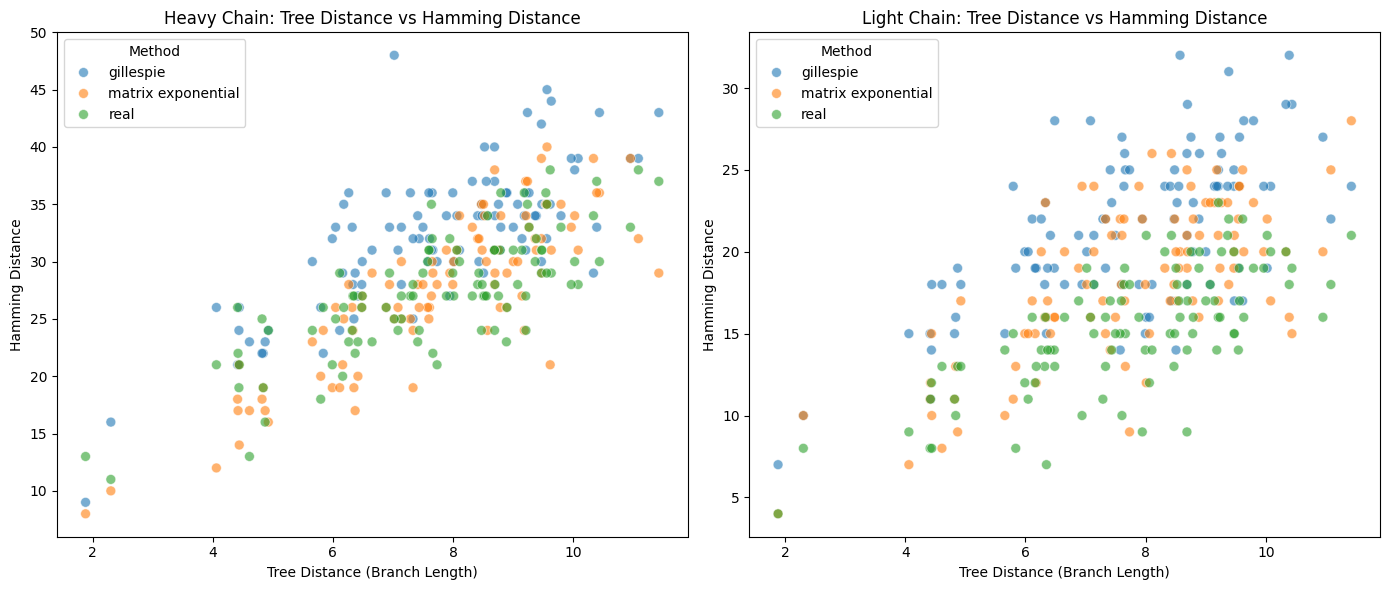

In [98]:
# plot distance versus hamming distance for each chain, colored by method

# Reshape data for plotting
_n = len(distances_df)
plot_df = pd.DataFrame({
    'distance': distances_df['distance'].tolist() * 3 + distances_df['distance'].tolist() * 3,
    'hamming_dist': (
        distances_df['gillespie_hv_hmd'].tolist() + 
        distances_df['mat_exp_hv_hmd'].tolist() + 
        distances_df['real_hv_hmd'].tolist() +
        distances_df['gillespie_lt_hmd'].tolist() + 
        distances_df['mat_exp_lt_hmd'].tolist() + 
        distances_df['real_lt_hmd'].tolist()
    ),
    'method': ['gillespie'] * _n + ['matrix exponential'] * _n + ['real'] * _n + 
              ['gillespie'] * _n + ['matrix exponential'] * _n + ['real'] * _n,
    'chain': ['heavy'] * (3 * _n) + ['light'] * (3 * _n)
})

# Create side-by-side plots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Heavy chain
sns.scatterplot(
    data=plot_df[plot_df['chain'] == 'heavy'], 
    x='distance', 
    y='hamming_dist', 
    hue='method', 
    ax=ax[0], 
    alpha=0.6,
    s=50
)
ax[0].set_title('Heavy Chain: Tree Distance vs Hamming Distance')
ax[0].set_xlabel('Tree Distance (Branch Length)')
ax[0].set_ylabel('Hamming Distance')
ax[0].legend(title='Method')

# Light chain
sns.scatterplot(
    data=plot_df[plot_df['chain'] == 'light'], 
    x='distance', 
    y='hamming_dist', 
    hue='method', 
    ax=ax[1], 
    alpha=0.6,
    s=50
)
ax[1].set_title('Light Chain: Tree Distance vs Hamming Distance')
ax[1].set_xlabel('Tree Distance (Branch Length)')
ax[1].set_ylabel('Hamming Distance')
ax[1].legend(title='Method')

plt.tight_layout()
plt.show()

In [100]:
gillespie_samples

{'Node1': 'EVQLVESGGGLVQPGGSLRLSCAASGFTFNSFEMNWVRQAPGKGLEWVSYISTSGSTIYYADSVKGRFTISRDNAKNSLYLHLNSLRAEDTAVYYCASGGYCTNGVCHTAEYFHFWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSINTWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQFNSYPWAFGQGTKVEIK',
 'Node2': 'EVQLVESGGGLVQPGGSLRLSCAASGFTFNSFEMNWVRQAPGKGLEWVSYISTSGSTIYYADSVKGRFTISRDNAKNSLYLHLHSLRAEDTAVYYCASGGYCSNGVCHTAEYFHFWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSINTWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQFNSYPWAFGQGTKVEIK',
 'Node97': 'EVQLVESGGGLVQPGGSLRLSCAASGFTFNSFEMNWVRQAPGKGLEWVSYISTSGSTIYYADSVKGRFTISRDNAKNSLYLHLNSLRAEDTAVYYCASGGYCTNGVCHTAEYFHFWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSINTWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQFNSYPWAFGQGTKVEIK',
 'Node3': 'EVQLVESGGDLVQPGGSLRLSCAASGFTFNSFEMNWVRQAPGKGLEWVSYISTSGSTIFYADSVKGRFTISRDNAKNSLYLHLYSLRADDTAVYYCASGGYCSNGVCHTSEYFHFWGQGTLVTVSS.DIQMTQSPSTLSASVGDRVTITCRASQSINTWLAWYQQKPGKAPKLLIYKASSLESGVPSRFSGSGSGTEFTLTISSLQPDDFATYYCQQFNSYPWAFGQGTKVEIK',
 'Node8

In [101]:
# save samples to results dir
# save each of mat_exp and gillespie to a separate df
# columns should include the name of node and the sampled sequence

# Create DataFrames for gillespie samples
gillespie_df = pd.DataFrame([
    {'node_name': node_name, 'sequence': seq_data}
    for node_name, seq_data in gillespie_samples.items()
])

# Create DataFrames for matrix exponential samples
mat_exp_df = pd.DataFrame([
    {'node_name': node_name, 'sequence': seq_data}
    for node_name, seq_data in mat_exp_samples.items()
])

# Save to CSV files
gillespie_df.to_csv("results/gen_eval/ctmc_gillespie_tree_samples.csv", index=False)
mat_exp_df.to_csv("results/gen_eval/ctmc_mat_exp_tree_samples.csv", index=False)

print(f"Saved {len(gillespie_df)} gillespie samples to results/gen_eval/ctmc_gillespie_tree_samples.csv")
print(f"Saved {len(mat_exp_df)} matrix exponential samples to results/gen_eval/ctmc_mat_exp_tree_samples.csv")

# Also save the pairwise distances dataframe
# distances_df.to_csv("results/gen_eval/ctmc_pairwise_distances.csv", index=False)
# print(f"Saved pairwise distances to results/gen_eval/ctmc_pairwise_distances.csv")

Saved 291 gillespie samples to results/gen_eval/ctmc_gillespie_tree_samples.csv
Saved 291 matrix exponential samples to results/gen_eval/ctmc_mat_exp_tree_samples.csv
